### **ACID - PART 3 - Control image quality**

**Author:** Alessandro Ulivi (alessandro.ulivi.89@gmail.com)

**Last update (yyyy/mm/dd):** 2025/12/16


## **---------------------------**

### Import required modules

Run the following cell.

Don't modify the following cell.

In [1]:
# Import required modules
import datetime
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
import napari
import seaborn as sns
import matplotlib.pyplot as plt
from utils.listdirNHF import listdirNHF
from utils.get_defaults import default_file_name
from utils.axis_utils import get_ch_number
from image_quality_control.measure_plls import compute_plls
# from utils.mksubdir import mk_subdir
# from image_processing.extract_metadata import extract_bioio_scene_metadata
# from image_processing.name_metadata import extract_name_metadata
# from image_processing.make_imagej_metadata import imagej_compatible_metadata_dict
# from utils.open_image import bioio_open_image
# from utils.save_image import tifffile_save_ometiff
# from image_processing.save_metadata import save_xml_string



### Specify the paths to input and output data directories - specify hyperparameters

Run the following cell.

Some parts of the following cell should be modified. The parts NOT to modify are under the line ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"

In [2]:
# indicate the path to the directory storing the metadata file - NOTE: this is expected to be the metadata_df saved
# from part1 notebook
# metadata_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\proc_metadata"
metadata_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\proc_metadata"

# indicate the path to the directory storing the fields of view
# fov_directory = r"Z:\AlessandroUlivi_Data\projects\ACID\data\proc\fov"
fov_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\data\proc\fov"

# # indicate the path to the directory where outputs will be saved
# output_directory = r"C:\Users\aless\OneDrive\Desktop\Ale\lab\CIID_IDIP\projects\ACID\develop\251205_train_test_split"


# name of the metadata file - NOTE: this is expected to be the metadata_df saved
# from part1 notebook
# the following options are possible:
# 1) write the full name (extension included) of the csv file
# 2) write "default" or any other version with a uppercase letter (e.g. "Default")
# 3) leave an empty string: ""
# 4) write None (NOTE that this is not a string, there are no "", aka it is not "None")
# Options 2,3 and 4 will lead to the same behavior: the most recently saved csv file will be used.
# By default, the timestap of the last file modification is used. As an alternative it is possible to use the
# date saved in the name (change below parameter metadata_from_file_name to True -
# see utils.get_defaults.default_file_name documentation).
metadata_file_name = "default"


# ""--- --- --- DON'T MODIFY THE FOLLOWING LINES --- --- ---"
# # --- parameters to select the train set ---
# indicate the name of the column indicating whether the row belongs to train or test set
is_train_column="is_train"

# indicate the value signalling that a row (aka a field of view) belongs to the train set
train_val=1

# # --- parameters used for importing the default metadata dataframe ---
# Indicate the part of the file name to use to select files into metadata_directory to be used for selecting the default
# file
default_metadata_file_target = ".csv"
default_metadata_file_exclude = None

# Indicate whether to extract the date information from the file name when selecting the default file
# If False, the date will be extracted from the file's last modified timestamp, if True, from the file name.
# If from_file_name is True, the parameters *_default_separator and *_default_date_position
# should be used to indicate, respectively the separator to use for splitting the file name into tokens and
# the position of the token containing the date information. In addition, the date format used to include the date in the file name
# should be indicated using the parameters *_default_date_format.
# For example, if metadata_from_file_name is True, and the file name is "251126_plate_layout.csv",
# "_" is used as separator, 0 as date position, and '%Y%m%d' as date format.
# Ref to utils.get_defaults.default_file_name for more details.
metadata_from_file_name = False

# separator - used to split the file name and extract the information token with the date
metadata_default_separator = '_'

# date position - the position of the date information token after splitting the file name using file_name_separator (above)
metadata_default_date_position = 0

# date format - the format used for including the date in the file name to be opened by default
metadata_default_date_format='%Y%m%d'

# reverse - if True, the file with the most recent date will be returned by default - if False, the opposite
metadata_default_reverse = True


# --- parameters for power quality control calculation ---
# channel axis to be passed to compute_plls in order to calculate the power log-log slope values of individual channels
channel_axis = 0

# field of view column name in the metadata dataframe
fov_column_name = "ome_tif_file_name"

# null value to be used to fill quality control metrics columns when they can't be calculated
null_value = np.nan

# plls column name
plls_column_name = "plls"


# --- parameters for metadata dataframe updating ---
# channel separator used when saving multiple channel measurements into single dataframe columns
ch_measurement_separator = '-'


# --- parameters for file saving ---
# separator used for saved file names
save_file_name_separator = '_'

# project
project_name = "ACID"

# ignore indexes when saving pandas dataframes as csv files
save_csv_index = False # if False, the index will not be saved as a separate column in the csv file

# metadata saving date format
metadata_date_format = '%Y%m%d'

# metadata savingword
metadata_savingword = "metadata"

# metadata file suffix
metadata_file_suffix = f"part{save_file_name_separator}3.csv"

# hyperparameters saving date format
hyperparameters_date_format = '%Y%m%d-%H%M%S'

# hyperparameters savingword
hyperparameters_savingword = "hyperparameters"

# hyperparameters file suffix
hyperparameters_file_suffix = f"part{save_file_name_separator}3.csv"


# --- parameters for saving secondary information ---
# indicate the name of the directory for saving secondary outputs -
# this directory is used to store the hyperparameters used per each run of the pipeline
secondary_output_directory = "secondary_output"
exist_ok = True # if the secondary output directory already exists, do not raise an error



### Create secondary output directory if it doesn't exist - this directory is used to store the hyperparameters used per each run of the pipeline

Run the following cell.

Don't modify the following cell.

In [3]:
# create the path to secondary_output directory
secondary_output_path = os.path.join(os.getcwd(), secondary_output_directory)

# create the secondary_output directory if it doesn't exist
if not os.path.exists(secondary_output_path):
    os.makedirs(secondary_output_path, exist_ok=exist_ok)


#### Open the metadata dataframe - this is expected to be the output of part 2

Run the following cell.

Don't modify the following cell.

In [4]:

# check if using the default metadata data frame (the most recently saved)
if metadata_file_name==None or metadata_file_name.lower()=="default" or metadata_file_name=="":
    
    # import target files in the metadata_directory
    metadata_files = listdirNHF(metadata_directory,
                                target=default_metadata_file_target,
                                exclude=default_metadata_file_exclude)
    
    # get the default metadata file
    metadata_file_name = default_file_name(file_list=metadata_files,
                                           from_file_name=metadata_from_file_name,
                                           directory_path=metadata_directory,
                                           separator=metadata_default_separator,
                                           date_position=metadata_default_date_position,
                                           date_format=metadata_default_date_format,
                                           reverse=metadata_default_reverse)
    
    print(f"using {metadata_file_name} as default metadata file")


# open the metadata file
metadata_df_i = pd.read_csv(os.path.join(metadata_directory, metadata_file_name))

# copy metadata_df
metadata_df = metadata_df_i.copy()

# # display the metadata dataframe
# metadata_df



using 20251205_ACID_metadata_part_2.csv as default metadata file


#### Select train data set - NOTE: the metadata_df is updated into a metadata_df which does not contain the test data

Run the following cell.

Don't modify the following cell.

In [5]:
# Select only the train set and update metadata_df
metadata_df = metadata_df[metadata_df[is_train_column] == train_val]

# assert proper selection of train set
assert metadata_df.shape[0] > 0, "No rows in metadata_df belong to the train set."
assert all(metadata_df[is_train_column] == train_val), "Not all rows in metadata_df belong to the train set."

# Display the metadata dataframe
metadata_df

,Unnamed: 0,raw_file_name,scene_name,processing_date_yymmdd,ome_tif_file_name,location,microscope,objective,experiment,condition1,...,size_c,size_z,size_y,physical_size_y,size_x,physical_size_x,dims_order,int_well,treatment,is_train
1,1,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A2,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
2,2,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A3,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
3,3,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A4,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A4...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
5,5,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A6,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
6,6,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A7,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A7...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,1,uninfected_nocpd,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,92,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G2,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1
93,93,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G3,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1
95,95,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G5,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G5...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1
96,96,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G6,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,5,1,1024,0.325,1024,0.325,CYX,5,infected_nocpd,1


#### Test PLLS computation

In [6]:
# get the number of channels in the images indicated in the metadata dataframe
num_channels = get_ch_number(metadata_df,
                             fov_directory,
                             fov_clm=fov_column_name,
                             channel_axis=channel_axis,
                             null_value=null_value)

# initialize a global collection list
glob_plls_collection_list = []


# iterate through the rows of the metadata dataframe
for i in metadata_df.index:

    print("---------    ---------")
    
    # ---------
    # OPEN FIELD OF VIEW AND SEGMENTATION
    # ---------

    # get the field of view file
    field_of_view_file = metadata_df.loc[i, fov_column_name]

    # try to calculate quality control values
    try:
        
        print(f"working on {field_of_view_file}")

        # open the field of view
        field_of_view = tifffile.imread(os.path.join(fov_directory, str(field_of_view_file)))

        # calculate the power law log-log slope of the Fourier transformation of the field of view, per each channel
        fov_plls = compute_plls(image=field_of_view,
                                axis=channel_axis)

        # collect power law log-log splope values into the collection list
        glob_plls_collection_list.append(fov_plls)

        # print message
        print(f"plls calculated")

    # add null values if quality control calculation fails:
    except:

        print(f"can't calculate image QC for {field_of_view_file}")

        # collect power law log-log splope values into the collection list
        glob_plls_collection_list.append([null_value for qc in range(num_channels)])


# concatenate measurements of all fields of view
glob_plls = np.stack(glob_plls_collection_list, axis=0)

# create column names for the power law log-log slope measurements
plls_column_names = [f"{plls_column_name}{ch_measurement_separator}{ch}" for ch in range(num_channels)]

# add measurements to the metadata dataframe
metadata_df[plls_column_names] = pd.DataFrame(glob_plls, index=metadata_df.index)

print("finished")



number of channels found: 5
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A3.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A4.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A7.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B7.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B6.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_B1.ome.tif
plls calculated
---------    ---------
working on H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_C1.ome.tif
plls calculated
---------    ---------
work

#### Display metadata df with quality controls measurements

Run the following cell.

Don't modify the following cell.

In [7]:
metadata_df

,Unnamed: 0,raw_file_name,scene_name,processing_date_yymmdd,ome_tif_file_name,location,microscope,objective,experiment,condition1,...,physical_size_x,dims_order,int_well,treatment,is_train,plls-0,plls-1,plls-2,plls-3,plls-4
1,1,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A2,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,1,uninfected_nocpd,1,-2.526234,-2.744117,-2.722718,-0.786678,-1.771697
2,2,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A3,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,1,uninfected_nocpd,1,-2.501430,-2.774278,-2.814690,-1.260386,-1.710170
3,3,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A4,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A4...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,1,uninfected_nocpd,1,-2.480514,-2.700401,-2.743692,-0.540378,-1.668931
5,5,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A6,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,1,uninfected_nocpd,1,-2.517223,-2.639588,-2.902793,-0.557359,-1.770929
6,6,H7_DENV2_MOI1_30h_fixed_stained_well1.nd2,A7,251205,H7_DENV2_MOI1_30h_fixed_stained_well1_A07p2_A7...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,1,uninfected_nocpd,1,-2.572245,-2.677081,-2.843396,-0.559250,-1.802896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,92,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G2,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G2...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,5,infected_nocpd,1,-2.551365,-3.016317,-2.746163,-2.253273,-1.659301
93,93,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G3,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G3...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,5,infected_nocpd,1,-2.608257,-3.048901,-2.809830,-2.212753,-1.720768
95,95,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G5,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G5...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,5,infected_nocpd,1,-2.616410,-3.036433,-2.701331,-2.355001,-1.751333
96,96,H7_DENV2_MOI1_30h_fixed_stained_well5.nd2,G6,251205,H7_DENV2_MOI1_30h_fixed_stained_well5_A07p2_G6...,Center for Integrative Infectious Disease Rese...,Nikon Ti2 - CSU-W1 - spinning disc,Nikon Apochromat Lambda-S 60x/1.40 Oil,A07.2,H7,...,0.325,CYX,5,infected_nocpd,1,-2.531932,-2.899006,-2.848729,-2.129183,-1.741911


#### Display fields of view with min-max QCs

Run the following cell.

Don't modify the following cell.

In [8]:
# istantiate napari viewer
napari_viewer = napari.Viewer()

for col in plls_column_names:
    # sort the dataframe by the plls column
    metadata_df_sorted = metadata_df.sort_values(by=col, ascending=True)

    # get the fov with the lowest plls value
    fov_plls_row_low = metadata_df_sorted.iloc[0][fov_column_name]

    # get the fov with the highest plls value
    fov_plls_row_high = metadata_df_sorted.iloc[-1][fov_column_name]

    # open the images
    img_low = tifffile.imread(os.path.join(fov_directory, str(fov_plls_row_low)))
    img_high = tifffile.imread(os.path.join(fov_directory, str(fov_plls_row_high)))

    # select the channel to visualize
    img_low = img_low.take(indices=int(col.split(sep=ch_measurement_separator)[-1]), axis=channel_axis)
    img_high = img_high.take(indices=int(col.split(sep=ch_measurement_separator)[-1]), axis=channel_axis)

    print(img_low.shape, img_high.shape)

    # visualize using napari
    napari_viewer.add_image(img_low, name=f"lowest {col}: {fov_plls_row_low}")
    napari_viewer.add_image(img_high, name=f"highest {col}: {fov_plls_row_high}")



(1024, 1024) (1024, 1024)
(1024, 1024) (1024, 1024)
(1024, 1024) (1024, 1024)
(1024, 1024) (1024, 1024)
(1024, 1024) (1024, 1024)


#### Visualize QCs

Run the following cell.

Don't modify the following cell.

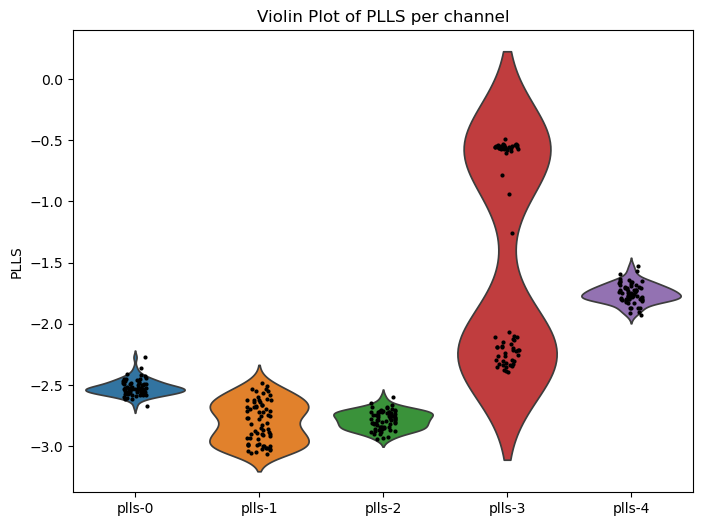

In [21]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

sns.violinplot(data=metadata_df[plls_column_names], ax=ax, inner=None)
sns.stripplot(data=metadata_df[plls_column_names], ax=ax, color='black', size=3)

ax.set_title("Violin Plot of PLLS per channel")
ax.set_ylabel("PLLS")

plt.show()


#### Add train-test split column to metadata dataframe and save the results

Run the following cell.

Don't modify the following cell.

In [10]:


# # save the metadata dataframe with train test split column
# # save metadata dataframe as a csv file
# metadata_saving_name = f"{datetime.datetime.now().strftime(metadata_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{metadata_savingword}{save_file_name_separator}{metadata_file_suffix}"
# metadata_df_w_split.to_csv(os.path.join(metadata_directory,metadata_saving_name), index=save_csv_index)

# # display metadata dataframe with train test split column
# metadata_df_w_split


### Save hyperparameters

Run the following cell.

Don't modify the following cell.

In [11]:
# # # collect hyperparameters in a dictionary

# hyperparameter_dict = {

# 'test_size':test_size,
# 'metadata_directory':metadata_directory,
# 'plate_layout_directory':plate_layout_directory,
# 'output_directory':output_directory,
# 'metadata_file_name':metadata_file_name,
# 'plate_layout_file_name':plate_layout_file_name,
# 'is_train_column':is_train_column,
# 'train_val':train_val,
# 'test_val':test_val,
# 'train_test_split_kwargs':train_test_split_kwargs,
# 'concat_kwargs':concat_kwargs,
# 'default_metadata_file_target':default_metadata_file_target,
# 'default_metadata_file_exclude':default_metadata_file_exclude,
# 'default_platelayout_file_target':default_platelayout_file_target,
# 'default_platelayout_file_exclude':default_platelayout_file_exclude,
# 'metadata_from_file_name':metadata_from_file_name,
# 'platelayout_from_file_name':platelayout_from_file_name,
# 'metadata_default_separator':metadata_default_separator,
# 'platelayout_default_separator':platelayout_default_separator,
# 'metadata_default_date_position':metadata_default_date_position,
# 'platelayout_default_date_position':platelayout_default_date_position,
# 'metadata_default_date_format':metadata_default_date_format,
# 'platelayout_default_date_format':platelayout_default_date_format,
# 'metadata_default_reverse':metadata_default_reverse,
# 'platelayout_default_reverse':platelayout_default_reverse,
# 'save_file_name_separator':save_file_name_separator,
# 'project_name':project_name,
# 'metadata_date_format':metadata_date_format,
# 'metadata_savingword':metadata_savingword,
# 'metadata_file_suffix':metadata_file_suffix,
# 'hyperparameters_date_format':hyperparameters_date_format,
# 'hyperparameters_savingword':hyperparameters_savingword,
# 'hyperparameters_file_suffix':hyperparameters_file_suffix,
# 'secondary_output_directory':secondary_output_directory,
# 'exist_ok':exist_ok
# }



# # transform the hyperparameter_dict in a pandas series
# hyperparameter_series = pd.Series(hyperparameter_dict)

# # save hyperparamters
# hyperparameter_saving_name = f"{datetime.datetime.now().strftime(hyperparameters_date_format)}{save_file_name_separator}{project_name}{save_file_name_separator}{hyperparameters_savingword}{save_file_name_separator}{hyperparameters_file_suffix}"
# hyperparameter_series.to_csv(os.path.join(secondary_output_directory,hyperparameter_saving_name), index=save_csv_index)

